# **Exploratory Data Analysis (EDA)**

# About Dataset

**📌 Netflix Dataset Description This dataset contains a comprehensive list of movies and TV shows available on Netflix, along with their metadata such as release year, genre, director, cast, country, and ratings. It is useful for exploratory data analysis (EDA), recommendation systems, and trend analysis in the streaming industry.**

# Dataset Information:
- **show_id:** Unique identifier for each title
- **type:** Content type - either "Movie" or "TV Show"
- **title :** Name of the movie or TV show
- **director:** Director(s) of the content (can be empty for some TV shows)
- **cast:** Comma-separated list of actors/actresses (can be empty)
- **country:** Country or countries where the content was produced (can be multiple, separated by commas)
- **date_added:** Date the title was added to Netflix (format: "Month DD, YYYY")
- **release_year:** Year the content was originally released
- **rating:** Content rating (e.g., PG-13, TV-MA, PG, TV-14, etc.)
- **duration:** How long the content is - for movies it's in minutes (e.g., "90 min"), for TV shows it's the number of seasons (e.g., "2 Seasons")
- **listed_in:** Genres/categories the title falls under (comma-separated)
- **description:** Plot summary or brief description of the content

# **Step 1: Summary Statistics**
- **The first step of any EDA is to understand the shape, structure, and basic statistical properties of the dataset. Summary statistics reveal the central tendency, spread, and missing data patterns.**

In [ ]:
# %pip install pandas
# %pip install numpy
# %pip install matplotlib
# %pip install seaborn
# %pip install scipy


In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

 - **Load & Inspect dataset**

In [178]:
df = pd.read_csv("DATA/netflix_titles.csv")
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [179]:
print("Shape:", df.shape)

Shape: (8807, 12)


In [180]:
print("Data types:",df.dtypes)

Data types: show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object


 - **Missing Value Analysis**

In [181]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y')

In [182]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7982 non-null   str           
 5   country       7976 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


In [183]:
df["date_added"]

0      2021-09-25
1      2021-09-24
2      2021-09-24
3      2021-09-24
4      2021-09-24
          ...    
8802   2019-11-20
8803   2019-07-01
8804   2019-11-01
8805   2020-01-11
8806   2019-03-02
Name: date_added, Length: 8807, dtype: datetime64[us]

In [184]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [185]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [186]:
#  Handel missing value
# df["director"].fillna("Unknown", inplace=True)
df.fillna({"director": "Unknown"}, inplace=True)
df.director.unique()

<StringArray>
[              'Kirsten Johnson',                       'Unknown',
               'Julien Leclercq',                 'Mike Flanagan',
 'Robert Cullen, José Luis Ucha',                  'Haile Gerima',
               'Andy Devonshire',                'Theodore Melfi',
             'Kongkiat Komesiri',           'Christian Schwochow',
 ...
       'Saratswadee Wongsomphet',             'Kirati Nakintanon',
                   'Mark Risley',                   'James Brown',
                    'Ivona Juka',                        'Mu Chu',
       'Chandra Prakash Dwivedi',               'Majid Al Ansari',
                  'Peter Hewitt',                   'Mozez Singh']
Length: 4529, dtype: str

In [187]:
# Cast Column has 825 missing value fill with unknown
df.fillna({"cast": "Unknown"}, inplace=True)
df.cast.unique()

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             'Unknown',
                                                                                                                                                                                                                                      'Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno Greeff, Xolile Tshabalala, Getmore Sithole, Cindy Mahlangu, Ryle De Morny, Greteli Fincham, Sello Maake Ka-Ncube, Odwa Gwa

In [188]:
# Country — fill with most frequent country (mode)
df.fillna({"country": df["country"].mode()[0]}, inplace=True)
df.country.unique()

<StringArray>
[                                                        'United States',
                                                          'South Africa',
                                                                 'India',
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
                                                        'United Kingdom',
                                               'Germany, Czech Republic',
                                                                'Mexico',
                                                                'Turkey',
                                                             'Australia',
                                          'United States, India, France',
 ...
                        'Germany, United States, United Kingdom, Canada',
          'Canada, India, Thailand, United States, United Arab Emirates',
                             'United States, East Germany, West Germany',
                   

In [189]:
# # Date_added — fill with the most frequent date (mode)
df.fillna({"date_added": df["date_added"].mode()[0]}, inplace=True)
df.date_added.unique()

<DatetimeArray>
['2021-09-25 00:00:00', '2021-09-24 00:00:00', '2021-09-23 00:00:00',
 '2021-09-22 00:00:00', '2021-09-21 00:00:00', '2021-09-20 00:00:00',
 '2021-09-19 00:00:00', '2021-09-17 00:00:00', '2021-09-16 00:00:00',
 '2021-09-15 00:00:00',
 ...
 '2018-09-27 00:00:00', '2017-03-23 00:00:00', '2016-12-25 00:00:00',
 '2016-11-30 00:00:00', '2017-10-23 00:00:00', '2017-11-04 00:00:00',
 '2015-08-05 00:00:00', '2018-12-06 00:00:00', '2016-03-09 00:00:00',
 '2020-01-11 00:00:00']
Length: 1714, dtype: datetime64[us]

In [190]:
# # Rating — fill with mode (most common rating)
df.fillna(df["rating"].mode()[0], inplace=True)
df.rating.unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR', 'TV-Y7-FV',       'UR']
Length: 17, dtype: str

In [191]:
# Drop three missing values in duration
df = df.dropna(subset=["duration"])  
# df.reset_index(drop=True, inplace=True)  # reset index after dropping

In [192]:
# Verify all missing values are handled
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [193]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8807 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8807 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.8 KB


In [194]:
df.shape

(8807, 12)

 - D**escriptive Statistics**

In [195]:
# Numeric column statistics
df.describe()

,date_added,release_year
count,8807,8807.000000
mean,2019-05-17 12:13:09.735437,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-04 00:00:00,2017.000000
75%,2020-08-18 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [39]:
print("Date Added Stats:")
print("Earliest date :", df['date_added'].min())
print("Latest date   :", df['date_added'].max())
print("Most common   :", df['date_added'].mode()[0])
print("Total non-null:", df['date_added'].count())

Date Added Stats:
Earliest date : 2008-01-01 00:00:00
Latest date   : 2021-09-25 00:00:00
Most common   : 2020-01-01 00:00:00
Total non-null: 8794


In [103]:
# Content type distribution
print(df["type"].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [107]:
# All movies type
movies = df[df["type"] == "Movie"]
movies.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [110]:
# All tv_shows type
tv_shows = df[df["type"] == "TV Show"]
tv_shows.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...


In [104]:
# Top 10 countries producing content
print(df["country"].value_counts().head(10))

country
United States     3649
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [105]:
# Rating distribution
print(df["rating"].value_counts())

rating
TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


 - **Summary Statistics Table**

- **Visualization - Content Type & Rating Distribution**

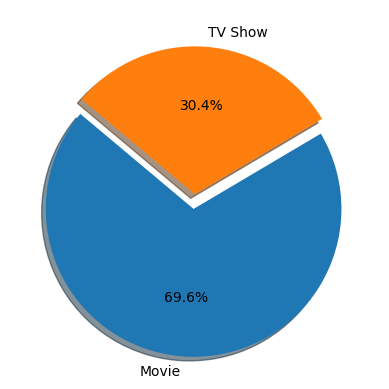

<Figure size 640x480 with 0 Axes>

In [111]:
# Plot 1: Content Type (Pie Chart)
type_counts = df["type"].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct="%1.1f%%", explode=(0.1, 0), shadow=True, startangle=140)
# axes[0].set_title("Content Type Distribution")
plt.show()
plt.savefig('content_type.png', dpi=150, bbox_inches='tight')

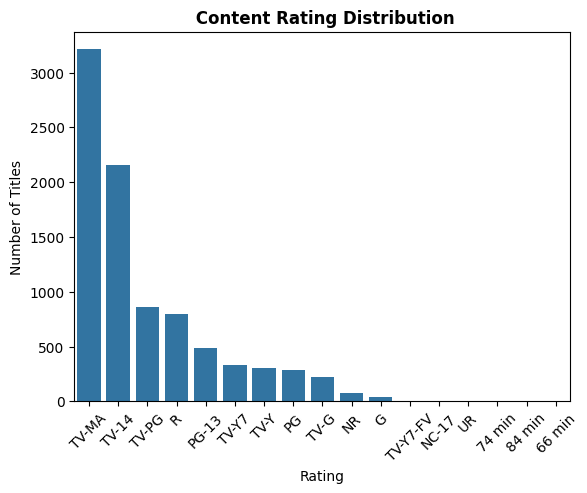

In [112]:
# Plot2 :Rating Distribution (Bar Chart)
rating_counts = df["rating"].value_counts()

sns.barplot(x = rating_counts.index , y = rating_counts.values
            )
plt.title(" Content Rating Distribution", fontweight='bold')
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [34]:
plt.tight_layout()
plt.savefig('content_type_rating.png', dpi=150, bbox_inches='tight')
plt.show()


<Figure size 640x480 with 0 Axes>

- **Graph 1 -Pie chart showa 69.6% Movies vs 30.4% TV Shows. Graph 2 - TV-MA and TV - 14 are the most common ratings, indicating Netflix adult audience primarily.**

# **Step 2: Correlation Analysis**
 - **Correlation analysis exlpores relationship between variables. For Netflix data, we examine correlations between release year, control duration, type, and country to find meaningful patterns**

 - **Feature Engineering for Correlation**

In [115]:
# Extract numeric duration for movies (in minutes)
# df['duration_int'] = df['duration'].str.extract('(\d+)').astype(int)
df['duration_int'] = df['duration'].str.extract('(\d+)', expand=False).apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\admin\AppData\Local\Temp\ipykernel_19284\512431361.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['duration_int'] = df['duration'].str.extract('(\d+)', expand=False).apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)


In [116]:
df['duration_int']

0        90
1         2
2         1
3         1
4         2
       ... 
8802    158
8803      2
8804     88
8805     88
8806    111
Name: duration_int, Length: 8807, dtype: int64

In [117]:
# Separate movies and TV shows
movies = df[df['type'] == 'Movie'].copy()
tv_shows = df[df['type'] == 'TV Show'].copy()

In [120]:
movies.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127


In [119]:
tv_shows.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1


In [121]:
# Extract year added from date_added column
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [122]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,2021,9
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,2021,9


- **Correlation - Release Year vs Duration (Movies)**

In [123]:
# Pearson correlation release year vs movies duration
corr, p_value = stats.pearsonr(movies['release_year'], movies['duration_int'])
print(f"Pearson r = {corr:.4f}, p-value = {p_value:.4f}")

Pearson r = -0.2058, p-value = 0.0000


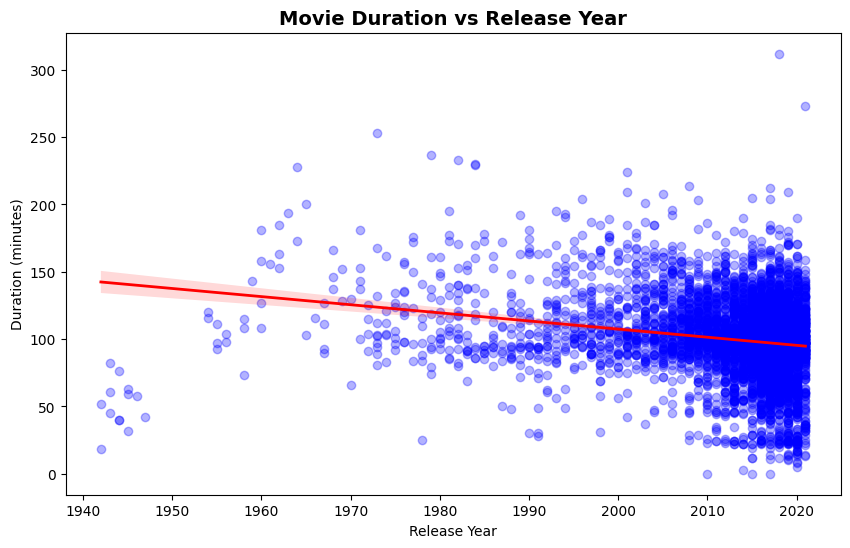

<Figure size 640x480 with 0 Axes>

In [124]:
# Scatter plot with regression line
plt.figure(figsize = (10,6))
sns.regplot(data = movies, x = 'release_year', y = 'duration_int',
            scatter_kws = {'alpha':0.3, 'color':'blue'},
            line_kws = {'color':'red', 'linewidth':2})
plt.title('Movie Duration vs Release Year', fontsize = 14, fontweight ='bold' )
plt.xlabel('Release Year')
plt.ylabel('Duration (minutes)')
plt.show()
plt.savefig('movie_duration_release_year.png', dpi=150, bbox_inches='tight')

 - **Insight A weak negative correlation(r= -0.21) suggests that more recently released movies tend to be slightly shorter on average. The trend is statistically significant (p < 0.05).**

- **Correlation Heatmap - Encoded Features**

In [125]:
# Encode type as binary (movie = 1, TV Show =0)
df['type_encoded'] = df['type'].map({'Movie': 1, 'TV Show':0})

In [126]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,year_added,month_added,type_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,2021,9,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,2021,9,0


In [127]:
# Correlation matrix
corr_cols = ['release_year', 'year_added','month_added','duration_int','type_encoded']
corr_matrix = df[corr_cols].corr()
corr_matrix

,release_year,year_added,month_added,duration_int,type_encoded
release_year,1.000000,0.111206,-0.038500,-0.249087,-0.181710
year_added,0.111206,1.000000,-0.161465,0.029010,-0.022967
month_added,-0.038500,-0.161465,1.000000,-0.014942,-0.017830
duration_int,-0.249087,0.029010,-0.014942,1.000000,0.884761
type_encoded,-0.181710,-0.022967,-0.017830,0.884761,1.000000


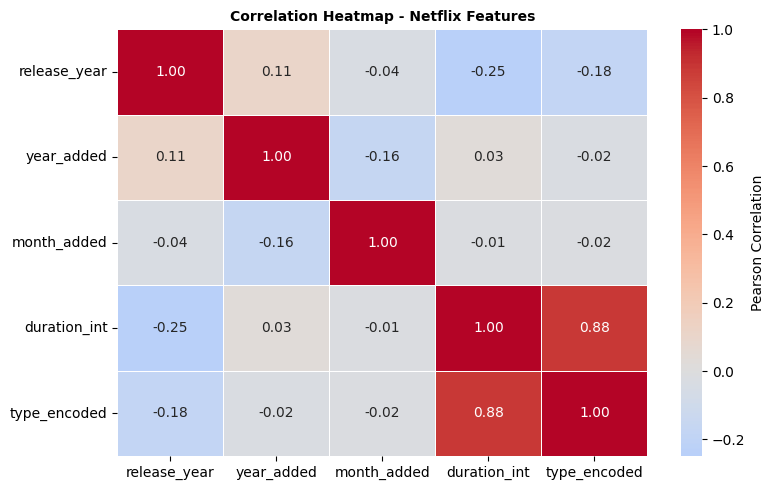

<Figure size 640x480 with 0 Axes>

In [130]:
plt.figure(figsize = (8,5))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f',          linewidths = 0.5, center = 0,
            cbar_kws = {'label':'Pearson Correlation'})
plt.title('Correlation Heatmap - Netflix Features', fontsize = 10, fontweight = 'bold')
plt.tight_layout()
plt.show()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')

- **Statistical Significance Testing**

 - **We perform hypothesis tests to confirm thst observed differeces between Movies and TV Shows are statistically significant, not due to random chance.**

In [131]:
from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu

In [132]:
# Test 1: Are movie duartions significantly different from TV show seasons?
movie_dur = movies['duration_int']
tv_show_dur = tv_shows['duration_int']
t_stat, p_value = ttest_ind(movie_dur, tv_show_dur)
print(f'T-statistic: {t_stat:.4f}, p-value:{p_value:.6f}')

T-statistic: 178.1406, p-value:0.000000


In [133]:
# Test 2: Chi- Square test  -is Rating independent of Content type?
contingency_table = pd.crosstab(df['rating'], df['type'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f'Chi-square statistic: {chi2:.2f}, p-value: {p_value:.6f}, df:{dof}')
print(contingency_table)

Chi-square statistic: 1047.86, p-value: 0.000000, df:16
type      Movie  TV Show
rating                  
66 min        1        0
74 min        1        0
84 min        1        0
G            41        0
NC-17         3        0
NR           75        5
PG          287        0
PG-13       490        0
R           797        2
TV-14      1427      733
TV-G        126       94
TV-MA      2064     1147
TV-PG       540      323
TV-Y        131      176
TV-Y7       139      195
TV-Y7-FV      5        1
UR            3        0


# **Step 3: Trend Identification**

- **Trend identification reveals how Netflix content has evolved over time - what kinds of content are growing, which countries dominate, which genres are rising, and when Netflix adds most content.**

 - **Trend 1:Content Growth Over Time**

In [134]:
# Titles added per year
yearly = df.groupby('year_added')['show_id'].count().reset_index()
yearly.columns = ['Year', 'Titles Added']
yearly

,Year,Titles Added
0,2008,2
1,2009,2
2,2010,1
3,2011,13
4,2012,3
5,2013,11
6,2014,24
7,2015,82
8,2016,429
9,2017,1188


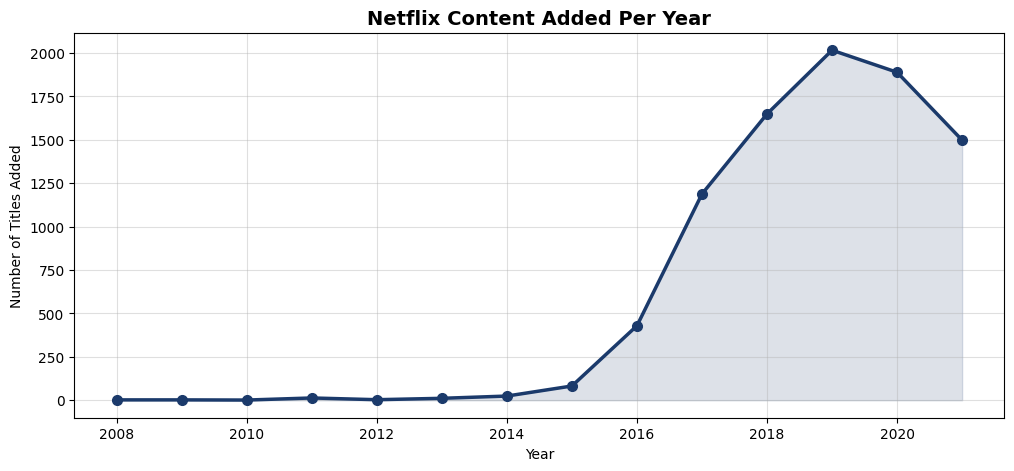

In [135]:
plt.figure(figsize=(12,5))
plt.plot(yearly['Year'], yearly['Titles Added'],
         marker = 'o', color = '#1B3A6B', linewidth = 2.5, markersize = 7)
plt.fill_between(yearly['Year'], yearly['Titles Added'], alpha = 0.15, color = '#1B3A6B')
plt.title('Netflix Content Added Per Year', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.grid(True, alpha = 0.4)
plt.savefig('content_added_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

 - **Insight: Netflix added very few titles before 2015. Growth accelerates sharply from 2016 to 2019. A slight drop in 2020 reflects pandemic- related production delays. Recovery began in 2021.**

- **Trend 2: Movies vs TV Shows Over Time**

In [136]:
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_int,year_added,month_added,type_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,2021,9,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,2021,9,0


In [137]:
# Type breakdwon per year
type_year = df.groupby(['year_added', 'type'])['show_id'].count().unstack()
type_year

type,Movie,TV Show
year_added,,
2008,1.0,1.0
2009,2.0,NaN
2010,1.0,NaN
2011,13.0,NaN
2012,3.0,NaN
2013,6.0,5.0
2014,19.0,5.0
2015,56.0,26.0
2016,253.0,176.0


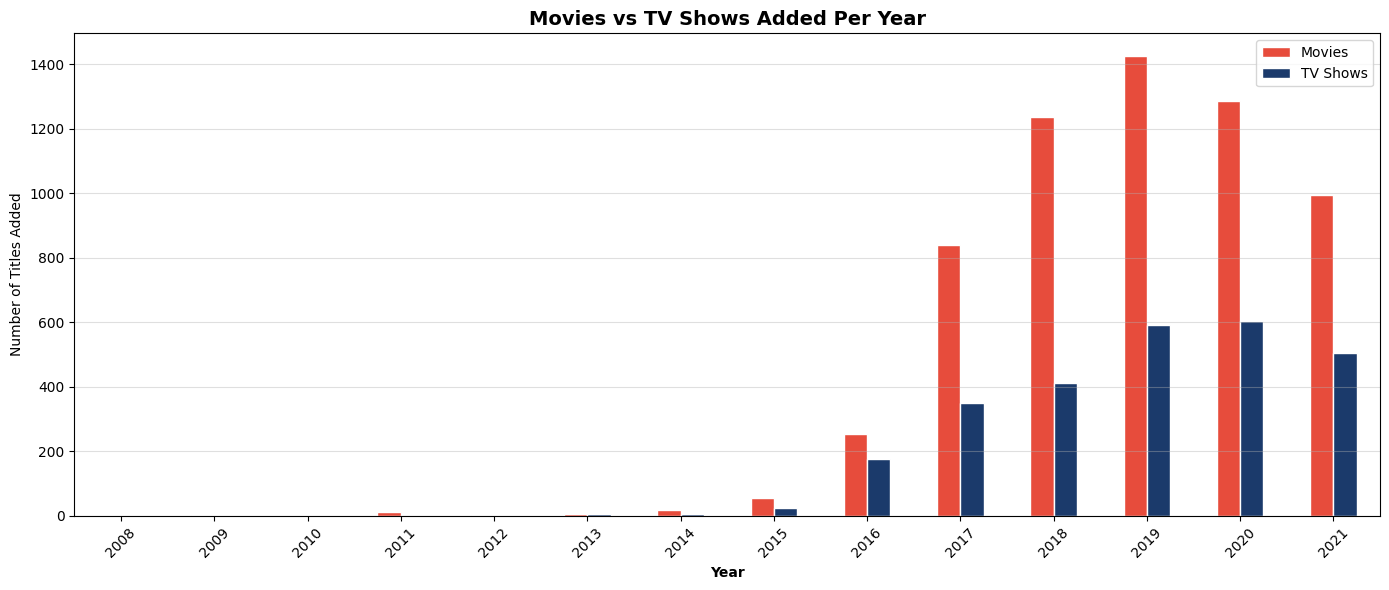

In [138]:
type_year.plot(kind = 'bar', figsize= (14,6), color =['#E74C3C','#1B3A6B'],
               edgecolor = 'white')
plt.title('Movies vs TV Shows Added Per Year', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year', fontweight = 'bold')
plt.ylabel('Number of Titles Added')
plt.legend(['Movies', 'TV Shows'])
plt.xticks(rotation = 45)
plt.grid(axis = 'y', alpha = 0.4)
plt.tight_layout()
plt.savefig('movies_vs_tv_shows_per_year.png', dpi=150, bbox_inches='tight')
plt.show()


- **Insight: Netflix consistently adds more Movies than TV Shows each year. However, the proportion of TV Shows has been growing since 2018, indicating a strategic shift toward episodic content.**

= **Trend 3: Top 10 Countries by Content**

In [139]:
# Top 10 countries
top_countries = df['country'].value_counts().head(10)
top_countries

country
United States     3649
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

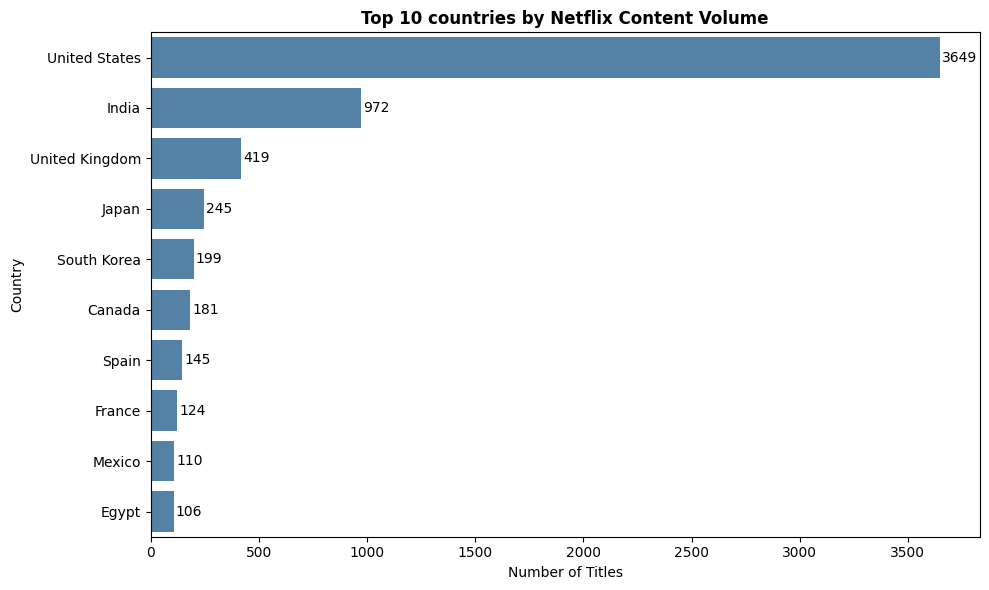

In [140]:
plt.figure(figsize = (10,6))
sns.barplot(y = top_countries.index, x = top_countries.values,
            color = 'steelblue')
plt.title('Top 10 countries by Netflix Content Volume', fontweight = 'bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
for i, v in enumerate(top_countries.values):
    plt.text(v + 10, i, str(v), va = 'center', color = 'black', fontsize = 10)
plt.tight_layout()
plt.savefig('top_10_countries.png', dpi=150, bbox_inches='tight')

- **Trend 4: Top Genres (Listed in)**

In [141]:
# Split multiple genres per title, count indivisually
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

C:\Users\admin\AppData\Local\Temp\ipykernel_19284\3019864054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_genres.values, y = top_genres.index,


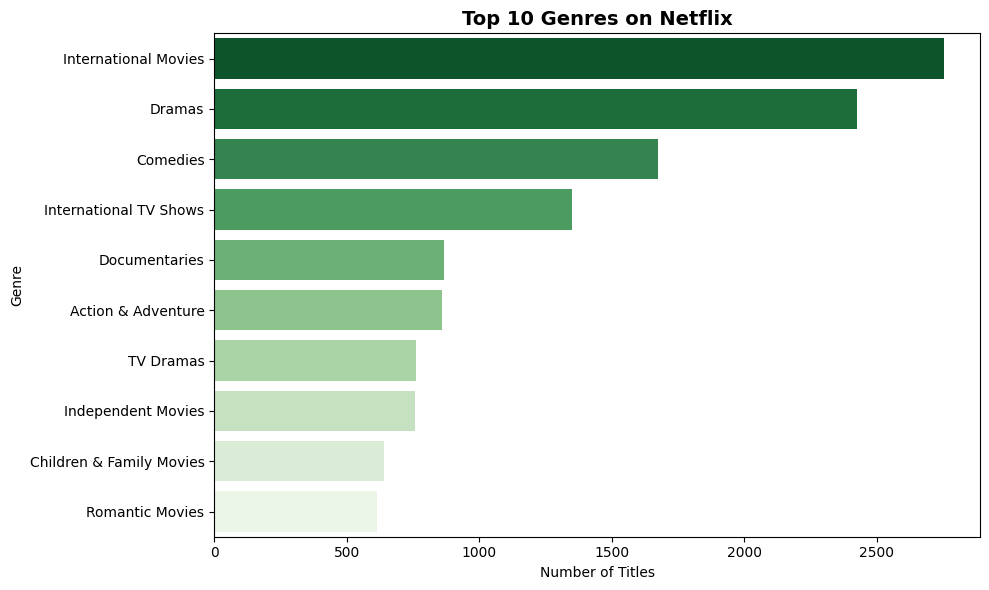

In [142]:
plt.figure(figsize = (10,6))
sns.barplot(x = top_genres.values, y = top_genres.index,
            palette = 'Greens_r')
plt.title('Top 10 Genres on Netflix', fontsize = 14, fontweight = 'bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('top_10_genres.png', dpi=150, bbox_inches='tight')

- **Insight: International Movies, Dramas, and Comedies are the three genres. International Tv Shows and Documentaries are also prominent, shwoing breadth in audience targeting.**

- **Trend 5: Monthly Content Addition Pattern**

In [143]:
# Which months does Netflix add the most content?
monthly = df.groupby('month_added')['show_id'].count().reset_index()
monthly = monthly.sort_values('month_added')  # Ensure months are in order Jan-Dec

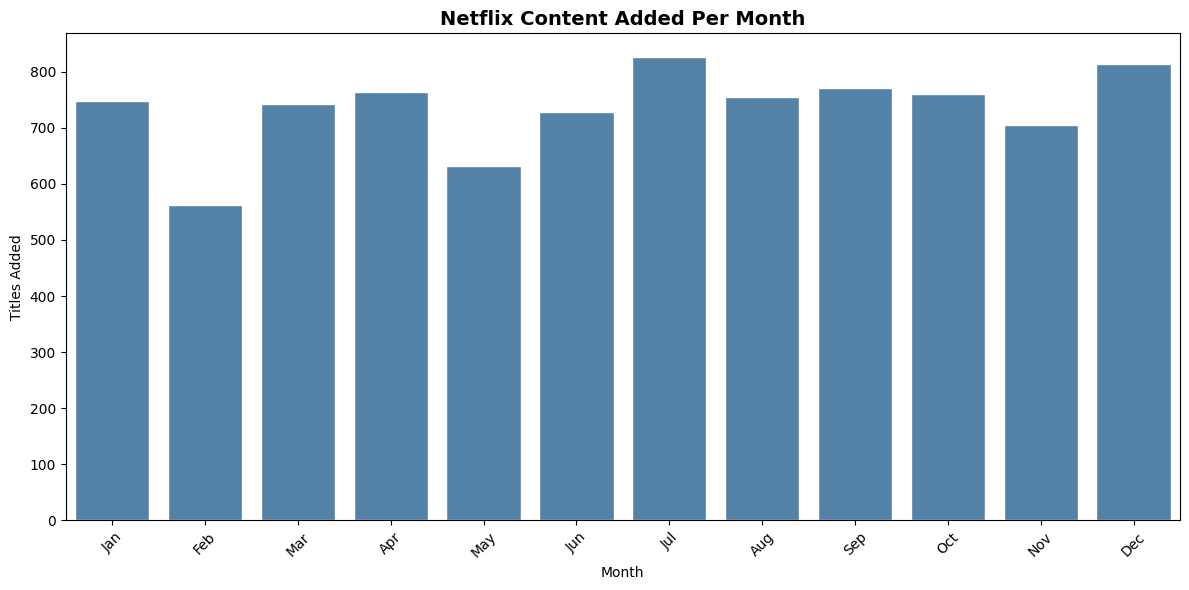

In [144]:
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly['month_added'], y=monthly['show_id'], color='steelblue', edgecolor='white')
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(range(len(monthly)), [month_names[int(m)-1] for m in monthly['month_added']], rotation=45)
plt.title('Netflix Content Added Per Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Titles Added')
plt.tight_layout()
plt.savefig('content_added_per_month.png', dpi=150, bbox_inches='tight')
plt.show()

- **Insight: Netflix adds the most content in July and December, aligning with major subscription renewal periods and school holidays globally.**